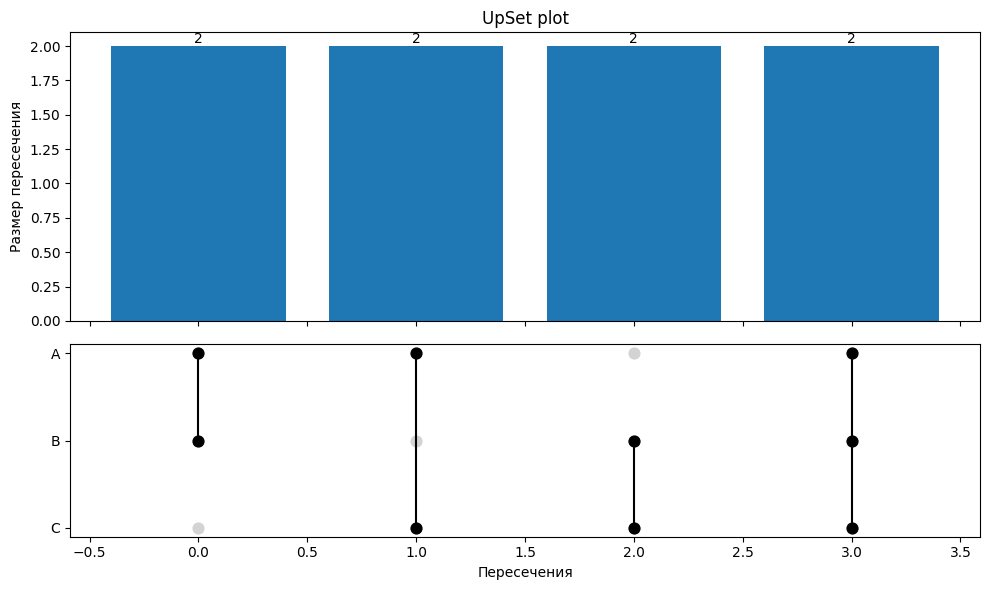

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def upset_plot(sets):
    names = list(sets.keys())
    n = len(names)

    # Находим все возможные пересечения
    intersections = []

    for mask in range(1, 2 ** n):
        selected = [i for i in range(n) if mask & (1 << i)]

        intersection = sets[names[selected[0]]].copy()

        for i in selected[1:]:
            intersection &= sets[names[i]]

        # Убираем элементы, которые входят в другие множества
        # То есть получаем точные пересечения
        not_selected = [i for i in range(n) if i not in selected]

        for i in not_selected:
            intersection -= sets[names[i]]

        if len(intersection) > 0:
            intersections.append(
                (selected, len(intersection))
            )

    # Сортируем по размеру пересечения
    intersections.sort(key=lambda x: x[1], reverse=True)

    counts = [x[1] for x in intersections]

    # Создаем два графика:
    # сверху столбики,
    # снизу матрица точек
    fig, (ax_bar, ax_matrix) = plt.subplots(
        2,
        1,
        figsize=(10, 6),
        gridspec_kw={
            "height_ratios": [3, 2]
        },
        sharex=True
    )

    # -------------------------
    # Столбики пересечений
    # -------------------------

    x = range(len(intersections))

    ax_bar.bar(x, counts)

    ax_bar.set_ylabel("Размер пересечения")
    ax_bar.set_title("UpSet plot")

    # Числа над столбцами
    for i, count in enumerate(counts):
        ax_bar.text(
            i,
            count,
            str(count),
            ha="center",
            va="bottom"
        )

    # -------------------------
    # Матрица точек
    # -------------------------

    for x_pos, (selected, count) in enumerate(intersections):

        # Серые точки для всех множеств
        for y in range(n):
            ax_matrix.scatter(
                x_pos,
                y,
                s=60,
                color="lightgray"
            )

        # Черные точки для участвующих множеств
        for y in selected:
            ax_matrix.scatter(
                x_pos,
                y,
                s=60,
                color="black"
            )

        # Линия между точками
        if len(selected) > 1:
            ax_matrix.plot(
                [x_pos, x_pos],
                [min(selected), max(selected)],
                color="black"
            )

    ax_matrix.set_yticks(range(n))
    ax_matrix.set_yticklabels(names)

    ax_matrix.set_xlabel("Пересечения")

    ax_matrix.invert_yaxis()

    plt.tight_layout()
    plt.show()

data = ('test.csv')

sets = {
    "A": {1, 2, 3, np.nan, 5, 6},
    "B": {2, 3, 4, np.nan, 6, 7},
    "C": {1, 3, 4, 5, np.nan, 7}
}

upset_plot(sets)